This function `subtract_background_by_color` takes an input image and optional lower and upper color bounds to create a mask for background subtraction. It converts the image to HSV color space, creates a mask based on the specified color range, and then applies the mask to the original image to separate the foreground.

Original Image:


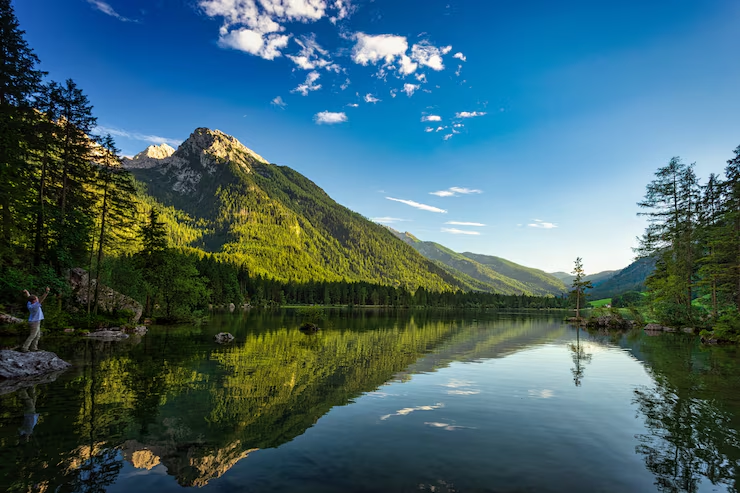

Foreground Image (Greenery):


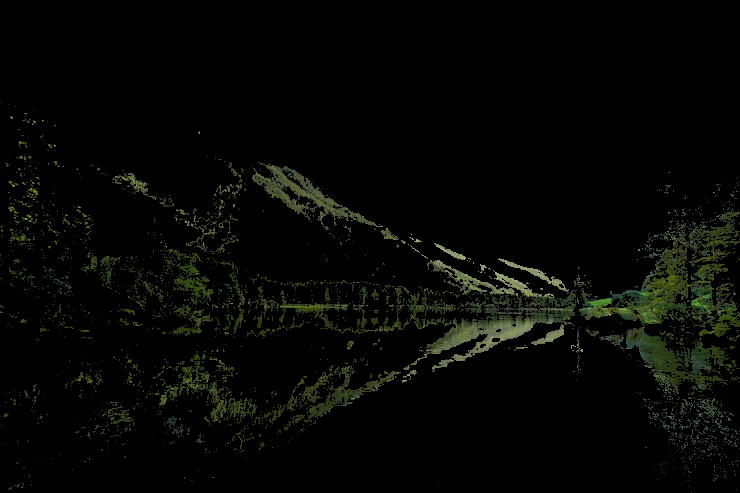

Mask:


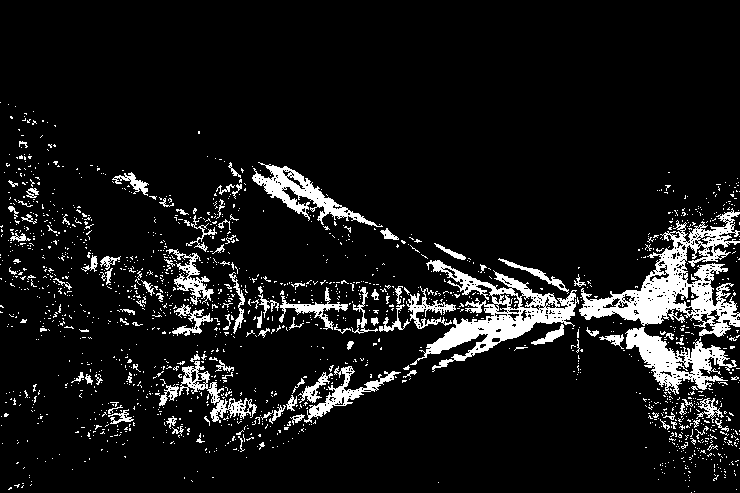

In [1]:
import cv2
import numpy as np

def subtract_background_by_color(image, lower_bound=np.array([0, 0, 0]), upper_bound=np.array([179, 255, 255])):
    """
    Subtracts the background of an image based on color levels using OpenCV.

    Args:
        image (numpy.ndarray): The input image (BGR format).
        lower_bound (numpy.ndarray): Lower bound of the color in HSV (e.g., np.array([H_min, S_min, V_min])).
                                    Defaults to black.
        upper_bound (numpy.ndarray): Upper bound of the color in HSV (e.g., np.array([H_max, S_max, V_max])).
                                    Defaults to white.

    Returns:
        tuple: A tuple containing:
            - numpy.ndarray: The foreground image with background subtracted (black background).
            - numpy.ndarray: The mask used for subtraction.
    """
    # Convert image from BGR to HSV color space
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Create a mask based on the color bounds
    # Pixels within the range will be white (255), others black (0)
    mask = cv2.inRange(hsv, lower_bound, upper_bound)

    # Invert the mask to get the foreground (if the specified range is for background)
    # Or use the mask directly if the specified range is for foreground
    # For background subtraction, we usually want to mask out the background.
    # Let's assume the provided bounds are for the *foreground* color.
    # If the bounds are for the *background*, simply invert the mask: mask = cv2.bitwise_not(mask)

    # Apply the mask to the original image
    result = cv2.bitwise_and(image, image, mask=mask)

    return result, mask

# Example usage:
# 1. Load an image (replace 'path/to/your/image.jpg' with your image file)
image = cv2.imread('/content/forest image.avif')

# For demonstration, let's create a dummy image with a blue rectangle on a white background
# dummy_image = np.full((300, 400, 3), 255, dtype=np.uint8) # White background
# cv2.rectangle(dummy_image, (100, 50), (300, 250), (255, 0, 0), -1) # Blue rectangle (BGR)

if image is not None:
    # Define the color range for the blue rectangle (foreground) in HSV
    # H: 100-140 (blue hue), S: 50-255 (saturation), V: 50-255 (value)
    # Define the color range for green (foreground) in HSV for forest image
    lower_green = np.array([35, 50, 50]) # Example bounds for green
    upper_green = np.array([85, 255, 255])

    foreground_image, mask = subtract_background_by_color(image, lower_green, upper_green)

    # print("Original Image (first 5x5 pixels of blue rectangle area):\n", dummy_image[50:55, 100:105, :])
    # print("Foreground Image (first 5x5 pixels of blue rectangle area):\n", foreground_image[50:55, 100:105, :])
    # print("Mask (first 5x5 pixels of blue rectangle area):\n", mask[50:55, 100:105])

    # To visualize the results (requires a display environment like Jupyter or a script that shows windows)
    from google.colab.patches import cv2_imshow
    print("Original Image:")
    cv2_imshow(image)
    print("Foreground Image (Greenery):")
    cv2_imshow(foreground_image)
    print("Mask:")
    cv2_imshow(mask)
else:
    print("Error: Could not load image. Please check the image path.")